In [5]:
%load_ext autoreload
%autoreload 2

# Define autoreload so that we don't have to reset the kernel every time after changing the files

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# Define the system paths
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parents[1] # Gets the GitHub repo folder
print(project_root)
sys.path.append(str(project_root))

# Import modules

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

C:\work\project\git-repo\FINCH-Science_SyntheticData
Using device: cuda


In [7]:
# load data
data_handle = str(project_root / "data" / "simpler_data_rwc.csv")
df = pd.read_csv(data_handle)
# spectral columns are numeric wavelength strings (400..2490 step 10) in training code
spec_cols = [str(w) for w in range(400, 2490 + 1, 10) if str(w) in df.columns]
spectra = df[spec_cols].values.astype("float32")
# abundances if present
abund_cols = [c for c in ["gv_fraction", "npv_fraction", "soil_fraction"] if c in df.columns]
if abund_cols:
    abundances = df[abund_cols].values.astype("float32")
else:
    abundances = np.zeros((len(df), 3), dtype="float32")

print("Loaded spectra shape:", spectra.shape, "abundances shape:", abundances.shape)

Loaded spectra shape: (1723, 210) abundances shape: (1723, 3)


In [9]:
from defs.diffusion.epsilon2 import Epsilon_MLP
from defs.diffusion.helper.noising.noising2 import CosSchedule
from defs.diffusion.diffusion2 import cond_diffusion
from defs.diffusion.training_defs.training_defs2 import train_diffusion
from defs.diffusion.training_defs.loss2 import loss_mse_sam

# model config matching epsilon2 expectations
cfg_model = {
    'time_embed': {'hidden_dim': 32, 'hidden_n': 2},
    'ab_embed': {'hidden_dim': 48, 'hidden_n': 3, 'ab_dim': 3},
    'denoiser': {'hidden_dim': 128, 'hidden_n': 4, 'spec_dim': len(spec_cols)}
}

# build epsilon network
epsilon = Epsilon_MLP(cfg_model=cfg_model, predict_logvar=True, cond_dropout=0.0)
epsilon.to(device)

# scheduler (construct then move internal tensors to device to avoid CPU/CUDA mix)
t_max = 1000
noise_schedule = CosSchedule(steps=t_max, offset=0.0008, exp=2)

# ensure any precomputed tensors inside the scheduler live on the requested device
for name, val in list(vars(noise_schedule).items()):
    if isinstance(val, torch.Tensor):
        setattr(noise_schedule, name, val.to(device))
noise_schedule.device = device

# wrap diffusion model (cond_diffusion expects epsilon, scheduler, optional cfg)
ddpm = cond_diffusion(epsilon=epsilon, scheduler=noise_schedule, cfg={"ema_decay": 0.9999})
ddpm.to(device)

# loss and optimizer
loss_fn = loss_mse_sam(ratio=0.01, use_logvar=True, hybrid_lambda=0.1)
optimizer = torch.optim.Adam(ddpm.epsilon.parameters(), lr=1e-4)

# training configuration for train_diffusion
cfg_train = {
    "device": str(device),
    "range": [400, 2490],
    "cfg_loader": {
        "test": 23,
        "validate": 4,
        "t_batch": 8,   # training batch size
        "epoch": 2,     # set small for quick test; increase as needed
        "seed": 0
    },
    "use_amp": False,
    "clip_grad": 1.0,
    "ema_every": 1,
    "save_every": 100000,
    "ckpt_dir": str(project_root / "checkpoints")
}

In [10]:
# run training
collector_dict, dl_train, dl_validate, dl_test, trained_ddpm = train_diffusion(cfg_train, ddpm, loss_fn, optimizer, data_handle=data_handle)

C:\work\project\git-repo\FINCH-Science_SyntheticData\defs\diffusion\training_defs\training_defs2.py:183: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
C:\work\project\git-repo\FINCH-Science_SyntheticData\defs\diffusion\training_defs\training_defs2.py:201: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1 | Average Training Loss: 8.107975
Epoch 1 | Average Validation Loss: 1.660077
Epoch 2 | Average Training Loss: 9.091718
Epoch 2 | Average Validation Loss: 1.660643
Average Test Loss: 1.676381


In [11]:
# sampling test using a single abundance
trained_ddpm.epsilon.eval()
with torch.no_grad():
    # get one batch from dl_test (dl_test batches are size 1 by default in training_defs2)
    try:
        sample_batch = next(iter(dl_test))
    except Exception:
        # fallback: use first row of abundances we loaded earlier
        ab = torch.from_numpy(abundances[:1]).to(device)
    else:
        ab = sample_batch['abundances'].to(device)

    x_gen, _ = trained_ddpm.sample(ab=ab, eta=0.0, guidance_scale=1.0)   # returns (x_0, x_T)
    x_gen = x_gen.detach().cpu().numpy()

MSE: 4.259988e+12, MAE: 1.627813e+06, SAM: 101.0572 deg


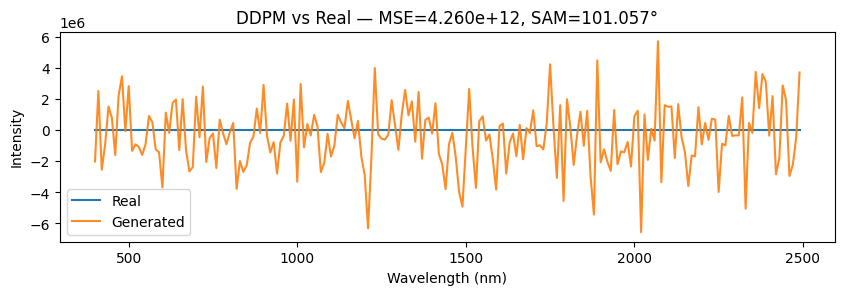

In [26]:
# generated vs real
# --- obtain generated sample (x_gen) ---
gen = None
if "x_gen" in globals():
    gen = np.array(x_gen)  # already CPU numpy if set earlier
else:
    # try to sample from trained_ddpm
    try:
        trained_ddpm.epsilon.eval()
        with torch.no_grad():
            # try test loader abundance if available
            try:
                sample_batch = next(iter(dl_test))
                ab = sample_batch.get("abundances", sample_batch.get("ab", None))
                if ab is None:
                    raise KeyError
                ab = ab.to(device)
            except Exception:
                # fallback to CSV-loaded abundances if available or zeros
                if 'abundances' in globals() and len(abundances) > 0:
                    ab = torch.from_numpy(abundances[:1]).to(device)
                else:
                    ab = torch.zeros((1,3), dtype=torch.float32, device=device)
            x_gen_t, _ = trained_ddpm.sample(ab=ab, eta=0.0, guidance_scale=1.0)
            gen = x_gen_t.detach().cpu().numpy()
    except Exception as e:
        print("Failed to sample from trained_ddpm:", e)

if gen is None:
    raise RuntimeError("No generated data available. Run the sampling cell first or ensure trained_ddpm exists.")

# ensure 1D spectrum for plotting
gen0 = gen[0].astype(np.float32) if gen.ndim > 1 else gen.astype(np.float32)

# --- obtain real spectrum (prefer test loader sample, else CSV-loaded spectra) ---
real0 = None
try:
    sample_batch = next(iter(dl_test))
    if isinstance(sample_batch, dict):
        for key in ("spectra", "x0", "spec", "data", "inputs"):
            if key in sample_batch:
                real0 = sample_batch[key][0].cpu().numpy().astype(np.float32)
                break
except Exception:
    pass

if real0 is None:
    # fallback to CSV-loaded spectra (first row)
    real0 = spectra[0].astype(np.float32)

# --- align lengths ---
L = min(len(gen0), len(real0))
g = gen0[:L]
r = real0[:L]

# --- decide normalization ---
gen_min, gen_max = float(np.nanmin(g)), float(np.nanmax(g))
is_gen_normalized = (gen_min >= -1.1 and gen_max <= 1.1)

if is_gen_normalized:
    # normalize real to [-1,1] per-sample
    rmin, rmax = r.min(), r.max()
    if rmax > rmin:
        r_plot = 2.0 * (r - rmin) / (rmax - rmin) - 1.0
    else:
        r_plot = r.copy()
    g_plot = g
    ylabel = "Normalized intensity (-1..1)"
else:
    # normalize generated to real range (or plot raw)
    g_plot = g
    r_plot = r
    ylabel = "Intensity"

# --- compute metrics ---
mse = float(np.mean((g_plot - r_plot) ** 2))
mae = float(np.mean(np.abs(g_plot - r_plot)))
dot = float(np.dot(g_plot, r_plot))
n1 = float(np.linalg.norm(g_plot))
n2 = float(np.linalg.norm(r_plot))
cosval = dot / (max(1e-12, n1 * n2))
cosval = np.clip(cosval, -1.0, 1.0)
sam_deg = float(np.degrees(np.arccos(cosval)))

print(f"MSE: {mse:.6e}, MAE: {mae:.6e}, SAM: {sam_deg:.4f} deg")


# --- plotting ---
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(wl, r_plot, label="Real (normalized)" if is_gen_normalized else "Real")
plt.plot(wl, g_plot, label="Generated", alpha=0.9)
plt.title(f"DDPM vs Real — MSE={mse:.3e}, SAM={sam_deg:.3f}°")
plt.xlabel("Wavelength (nm)")
plt.ylabel(ylabel)
plt.legend()
